# MLflow Observability for LangGraph


Observability（可觀測性）讓我們查看 Agent 執行期間發生了什麼，例如：

- 使用者輸入與模型輸出
- LLM 呼叫與工具呼叫
- 每個步驟的執行順序與耗時
- 錯誤發生在哪個節點
- 不同請求之間的行為差異

本例使用 MLflow Tracing 觀察一個會使用工具的 LangGraph Agent。

## 1. 啟動 MLflow Server

請先在另一個 terminal 自行啟動 MLflow；這個 cell 不會幫你啟動 server。

```powershell
mlflow server --host 127.0.0.1 --port 5000
```

啟動後可以在瀏覽器開啟：<http://127.0.0.1:5000>

## 2. Import libraries

In [1]:
import os
from typing import Dict

import mlflow
import requests
from IPython.display import Image, display
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode

## 3. 連線到 MLflow Tracking Server

Tracking URI 告訴 MLflow 要把 traces 寫到哪個 server。預設使用 port 5000，也可以用系統環境變數 `MLFLOW_TRACKING_URI` 覆蓋。

In [2]:
tracking_uri = os.getenv(
    "MLFLOW_TRACKING_URI",
    "http://127.0.0.1:5000",
)

mlflow.set_tracking_uri(tracking_uri)
print("MLflow tracking URI:", mlflow.get_tracking_uri())

MLflow tracking URI: http://127.0.0.1:5000


In [3]:
# 先確認 server 已經啟動，避免到後面才發現無法寫入 trace。
try:
    health_response = requests.get(f"{tracking_uri}/health", timeout=3)
    health_response.raise_for_status()
    print("MLflow server is ready.")
except requests.RequestException as error:
    raise RuntimeError(
        f"無法連線到 {tracking_uri}。請先在另一個 terminal 啟動 MLflow server。"
    ) from error

MLflow server is ready.


## 4. 建立 Experiment

Experiment 是 MLflow 中整理 traces 與 runs 的容器。相同專案的請求通常放在同一個 Experiment，方便搜尋與比較。

In [4]:
experiment = mlflow.set_experiment("langgraph-observability")

print("Experiment name:", experiment.name)
print("Experiment ID:  ", experiment.experiment_id)

2026/09/22 12:24:28 INFO mlflow.tracking.fluent: Experiment with name 'langgraph-observability' does not exist. Creating a new experiment.


Experiment name: langgraph-observability
Experiment ID:   2


## 5. Trace 與 Span

- **Trace**：一次完整請求的端到端紀錄。
- **Span**：Trace 裡的一個步驟，例如 LLM、Tool 或 Node 呼叫。

`@mlflow.trace` 可以讓一般 Python 函式也出現在 MLflow Tracing UI。

In [5]:
@mlflow.trace(name="add_numbers", span_type="TOOL")
def add(a: int, b: int) -> int:
    return a + b


add(1, 2)

3

執行後可以到 MLflow UI 的 Traces 頁面查看函式輸入、輸出、狀態與耗時。

## 6. 建立 LLM

請先設定系統環境變數 `OPENAI_API_KEY`。若課程環境使用自訂 endpoint，也可以設定 `OPENAI_BASE_URL`。

In [6]:
llm_options = {
    "api_key": os.environ["OPENAI_API_KEY"],
    "model": os.getenv("OPENAI_MODEL", "gpt-4o-mini"),
    "temperature": 0.0,
}

if os.getenv("OPENAI_BASE_URL"):
    llm_options["base_url"] = os.environ["OPENAI_BASE_URL"]

llm = ChatOpenAI(**llm_options)

Trace(trace_id=tr-f1bf9ad578f2138651283c8e02b0fafb)

## 7. 建立可觀察的工具

為了讓練習不依賴外部搜尋服務，本例使用本機首都資料。LLM 仍會透過標準 Tool Calling 決定並執行工具。

In [7]:
@tool
def lookup_country_capital(country: str) -> Dict[str, str]:
    """查詢指定國家的首都；country 請使用英文國名。"""
    capitals = {
        "brazil": "Brasília",
        "japan": "Tokyo",
        "mexico": "Mexico City",
        "taiwan": "Taipei",
    }
    normalized_country = country.strip().lower()

    if normalized_country not in capitals:
        return {
            "country": country,
            "error": "Country not found in the demo knowledge base",
        }

    return {
        "country": country,
        "capital": capitals[normalized_country],
    }

## 8. 建立 LangGraph Agent

In [8]:
class State(MessagesState):
    question: str
    answer: str


tools = [lookup_country_capital]
llm_with_tools = llm.bind_tools(tools)

In [9]:
def entry_point(state: State):
    return {
        "messages": [
            SystemMessage(
                "你是地理助理。回答國家首都問題時，必須先使用工具查詢，"
                "再根據工具結果用繁體中文回答。"
            ),
            HumanMessage(state["question"]),
        ]
    }


def agent(state: State):
    ai_message = llm_with_tools.invoke(state["messages"])
    return {
        "messages": [ai_message],
        "answer": ai_message.content,
    }


def router(state: State):
    last_message = state["messages"][-1]
    return "tools" if last_message.tool_calls else END

In [10]:
workflow = StateGraph(State)
workflow.add_node("entry_point", entry_point)
workflow.add_node("agent", agent)
workflow.add_node("tools", ToolNode(tools))

workflow.add_edge(START, "entry_point")
workflow.add_edge("entry_point", "agent")
workflow.add_conditional_edges(
    "agent",
    router,
    {"tools": "tools", END: END},
)
workflow.add_edge("tools", "agent")

graph = workflow.compile()

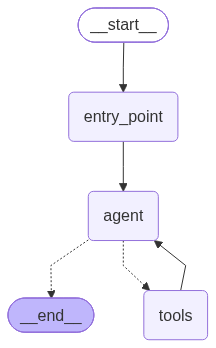

In [11]:
display(Image(graph.get_graph().draw_mermaid_png()))

## 9. 開啟 LangChain／LangGraph Autologging

請在執行 Graph 之前呼叫 `autolog()`。MLflow 會自動記錄支援的 LangChain 與 LangGraph 呼叫，建立 LLM、Chain、Tool 等 spans。

In [12]:
mlflow.langchain.autolog(
    log_traces=True,
    run_tracer_inline=True,
)

## 10. 執行並追蹤 Agent

外層的 `@mlflow.trace` 建立整體請求 Trace；autologging 則在裡面記錄 Graph、LLM 與 Tool 的細節。

In [13]:
@mlflow.trace(name="capital_agent_request", span_type="CHAIN")
def run_agent(question: str):
    mlflow.update_current_trace(
        tags={
            "application": "langgraph-course",
            "use_case": "capital-lookup",
        }
    )
    return graph.invoke(
        {
            "question": question,
            "messages": [],
            "answer": "",
        }
    )

In [14]:
result = run_agent("巴西的首都是哪裡？")

print("Final answer:")
print(result["messages"][-1].content)

Final answer:
巴西的首都是巴西利亞（Brasília）。


在 MLflow UI 中，這次請求通常可以看到類似以下階層：

```text
capital_agent_request
└─ LangGraph invocation
   ├─ entry_point
   ├─ agent / ChatOpenAI
   ├─ lookup_country_capital
   └─ agent / ChatOpenAI
```

實際 span 名稱與階層可能依 MLflow、LangChain 和 LangGraph 版本略有不同。

## 11. 從 Python 查詢 Traces

除了 UI，也可以用程式查詢最近的 traces，適合除錯、分析或建立監控報表。

In [15]:
traces = mlflow.search_traces(
    experiment_ids=[experiment.experiment_id],
    max_results=10,
    order_by=["timestamp_ms DESC"],
)

display(traces.head())

C:\Users\shich\AppData\Local\Temp\ipykernel_34084\2426419889.py:1: FutureWarning: Parameter 'experiment_ids' is deprecated. Please use 'locations' instead.
  traces = mlflow.search_traces(


,trace_id,trace,client_request_id,state,request_time,execution_duration,request,response,trace_metadata,tags,spans,assessments
0,tr-9be6e314bc5aa53fe6b6bfd1e07d859d,"{""info"": {""trace_id"": ""tr-9be6e314bc5aa53fe6b6...",None,OK,1790051157028,3281,{'question': '巴西的首都是哪裡？'},{'messages': [{'content': '你是地理助理。回答國家首都問題時，必須...,"{'mlflow.traceOutputs': '{""messages"": [{""conte...","{'application': 'langgraph-course', 'mlflow.ar...","[{'trace_id': 'm+bjFLxapT/mtr/R4H2FnQ==', 'spa...",[]
1,tr-f1bf9ad578f2138651283c8e02b0fafb,"{""info"": {""trace_id"": ""tr-f1bf9ad578f213865128...",None,OK,1790051075943,74,"{'a': 1, 'b': 2}",3,"{'mlflow.source.git.branch': 'main', 'mlflow.t...",{'mlflow.artifactLocation': 'file:C:/work/cour...,"[{'trace_id': '8b+a1XjyE4ZRKDyOArD6+w==', 'spa...",[]


Trace(trace_id=tr-9be6e314bc5aa53fe6b6bfd1e07d859d)

## 12. 多執行幾次以比較 Traces

不同問題會產生不同 traces。可以在 UI 比較耗時、工具參數、模型輸出與錯誤。

In [ ]:
questions = [
    "日本的首都是哪裡？",
    "墨西哥的首都是哪裡？",
]

for question in questions:
    response = run_agent(question)
    print(question, "→", response["messages"][-1].content)

## Observability 重點整理

| 概念 | 用途 |
|---|---|
| Tracking URI | 指定 MLflow server 位址 |
| Experiment | 將同一專案的 traces 分組 |
| Trace | 一次完整請求的端到端紀錄 |
| Span | Trace 中的一個 LLM、Tool、Node 或函式步驟 |
| `@mlflow.trace` | 手動追蹤自訂 Python 函式 |
| `mlflow.langchain.autolog()` | 自動追蹤 LangChain／LangGraph 呼叫 |
| Tags | 標記應用、環境或 use case，方便搜尋 |
| `search_traces()` | 從 Python 查詢 traces |

### 實務注意事項

- Trace 可能包含 prompt、模型回答與工具輸出，不要記錄密碼、API key 或不必要的個人資料。
- Observability 不等於 Evaluation。Tracing 告訴你流程發生了什麼；Evaluation 則判斷回答品質是否達標。
- 追蹤會增加少量延遲與儲存成本，正式環境應設定保留期限與取樣策略。
- 工具型 Agent 最值得觀察的是：是否選對工具、工具參數是否正確、失敗後是否能恢復，以及最終回答是否忠於工具結果。
- 如果 Graph 使用 interrupt/checkpoint，一次業務任務可能分成暫停前與恢復後的多次呼叫；分析 traces 時要搭配 `thread_id` 或自訂 tags。

## 常見問題

### 無法連線到 port 5000

確認 MLflow server 已啟動，且 `MLFLOW_TRACKING_URI` 與 server 位址一致。

### UI 中沒有 Trace

確認已在 Graph 執行前呼叫 `mlflow.langchain.autolog()`，並確認目前 Experiment 正確。

### Trace 有 Graph，但沒有 Tool

模型可能選擇直接回答。檢查 system prompt、工具描述及 AIMessage 的 `tool_calls`。

### 變更 tracking server 後資料不見了

Traces 儲存在 tracking server 的 backend store。連到不同 URI，看到的 Experiment 與 Trace 也不同。